# Session 4 — Demo 1 — The luck machine

**What this demo covers.** Pure chance produces differences all the time, so "group A is faster" means nothing until you know *how big a difference luck alone makes*. We build that machine with our own hands: the **permutation test**. One picture will define the p-value better than any formula.

**How we work tonight.** Same four steps as session 3. This is the shape HW1 Part 2 asks for:

- ❓ **Question** — what someone actually wants to know
- 🔍 **What we'll do** — *hidden behind a triangle: think about it first, then open it*
- ✅ **What it means** and ⛔ **what it does NOT mean**

> 🖼 **Cards for tonight:** `concept-cards.html`, in this same folder. **Card 1** is the p-value read off one picture, the one we are about to draw. Open it in a second tab. **Card 2** tells the same story the way a statistics course tells it, in five steps, and two of its pictures move when you drag them.

**Data.** The ALPHA week — [data dictionary](../../data/README.md).

**How to run.** Locally: top to bottom. Colab: uncomment the lines in the setup cell. Needs `scipy` (see the pip hint).

## 0. Setup

Same two lines of imports as session 3, plus one new library, `numpy`. We meet it properly in section 3, right before we need it.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import AutoMinorLocator

# where the data lives, relative to this notebook
DATA = Path("../../data/alpha")

# --- Google Colab? Uncomment these two lines to fetch the course repo: ---
# !git clone https://github.com/seemsGoodNow/hse-data-science-course.git course
# DATA = Path("course/data/alpha")

# missing a library? uncomment:
# %pip install pandas pyarrow matplotlib seaborn scipy

In [2]:
def make_ax_better(ax, minor=""):
    """Tidy one chart: drop the top/right frame, add a light grid.

    minor="x", "y" or "xy" also adds small ticks between the labelled ones.
    """
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    if "x" in minor:
        ax.xaxis.set_minor_locator(AutoMinorLocator())
    if "y" in minor:
        ax.yaxis.set_minor_locator(AutoMinorLocator())
    if minor:
        ax.tick_params(which="minor", length=2.5)
        ax.tick_params(which="major", length=5)
        ax.grid(which="minor", linewidth=0.15, color="tab:grey", alpha=0.25)
    ax.grid(linewidth=0.5, color="tab:grey", alpha=0.25)

---

## 1. The table we already know

Session 3 ended with a dodge: *"sectors **look** different — is that a difference or is it luck?"* To answer it we need last week's per-task table back, with the course metric on it: **`picks_per_hour`**, successful picks divided by the hours the task ran. Bigger is faster. It is the same column you met in session 3 and the same one HW1 Part 1 asks you to define.

You built that table in four visible steps last week, so here it is as one expression: the four steps collapsed, printed counts included. (Write it this way **after** you have checked the pieces, never instead of checking them.)

In [3]:
events = pd.read_parquet(DATA / "picking_events.parquet")
topology = pd.read_parquet(DATA / "topology.parquet")

picks = events[events["event_type"] == "PickCorrectItem"]
finished_ids = set(events.loc[events["event_type"] == "FinishTask", "task_id"])

tasks = (
    events
    .groupby("task_id")
    .agg(
        start=("event_time", "min"),
        end=("event_time", "max"),
    )
)
tasks["picks"] = picks.groupby("task_id").size()
tasks["picks"] = tasks["picks"].fillna(0).astype(int)
tasks["finished"] = tasks.index.isin(finished_ids)

print(
    f"all tasks: {len(tasks):,}   "
    f"unfinished: {(~tasks['finished']).sum():,}   "
    f"zero picks: {(tasks['picks'] == 0).sum():,}"
)

tasks = tasks[tasks["finished"] & (tasks["picks"] > 0)]
tasks["duration_min"] = (tasks["end"] - tasks["start"]).dt.total_seconds() / 60
tasks["picks_per_hour"] = tasks["picks"] / (tasks["duration_min"] / 60)
print(f"kept for pace stats: {len(tasks):,}")

all tasks: 4,237   unfinished: 160   zero picks: 0
kept for pace stats: 4,077


One column is new: which **sector** the task was picked in. It comes from the topology table by the same join as session 2. We state the two things we are about to assume out loud, as `assert` tripwires (the habit from session 2): every task stays inside one sector, and every task got a sector. (`.all()` on a True/False column asks "are they all True?", the same family as the `.mean()` we use for shares.)

Session 3 stored the sector id as text, because an id is a label you never average. Tonight the sector only ever appears inside an `==`, so a plain whole number is enough, and the second `assert` is what makes that switch safe. Both spellings are fine. The one that is never fine is the float form: session 1's rule, *a float id means hidden nulls*.

In [4]:
picks_with_sector = picks.merge(
    topology[["cell_id", "sector_id"]],
    on="cell_id",
    how="left",
)
sectors_per_task = picks_with_sector.groupby("task_id")["sector_id"].nunique()

# a task in this warehouse never leaves its sector - if that ever breaks,
# "the sector of a task" stops meaning anything and this line stops the notebook
assert sectors_per_task.max() == 1, "some task touched more than one sector"

tasks["sector"] = picks_with_sector.groupby("task_id")["sector_id"].first()
assert tasks["sector"].notna().all(), "some task has no sector"

tasks["sector"] = tasks["sector"].astype(int)
tasks[["picks", "picks_per_hour", "sector"]].head(3)

,picks,picks_per_hour,sector
task_id,,,
800000001,12,64.469048,6794
800000002,16,112.204149,5402
800000003,46,92.536765,6794


---

## 2. ❓ "Sector 5761 looks faster than 5130 — is it?"

<details>
<summary>🔍 <b>What we'll do</b> — how would you decide? Think first, then open</summary>

Take the pace of every task in each of the two sectors, and put their medians next to each other. Median, not mean: session 3 showed these paces have a long right tail.
</details>

One reading note for the cell below. `{value:+.2f}` prints two decimals and **always keeps the sign**, because tonight the sign is half the answer: plus means the first sector came out faster, minus means the second one did.

In [5]:
pace_5761 = tasks.loc[tasks["sector"] == 5761, "picks_per_hour"].dropna()
pace_5130 = tasks.loc[tasks["sector"] == 5130, "picks_per_hour"].dropna()

observed_difference = pace_5761.median() - pace_5130.median()
print(
    f"sector 5761: median {pace_5761.median():.1f} picks/h (n = {len(pace_5761)})\n"
    f"sector 5130: median {pace_5130.median():.1f} picks/h (n = {len(pace_5130)})\n"
    f"observed difference: {observed_difference:+.2f} picks/h"
)

sector 5761: median 135.3 picks/h (n = 304)
sector 5130: median 133.5 picks/h (n = 621)
observed difference: +1.80 picks/h


Sector 5761 looks a touch faster, by not even two picks an hour, on a pace of about 134. **Real, or luck?**

Nothing we learned so far can answer that. Two medians are two numbers; they will *always* differ a little. The question is whether they differ **more than random labelling would produce**. So let's produce random labelling and look.

---

## 3. New tool — `numpy`, and one shuffle by hand

To simulate luck we need to shuffle *values* between two groups. Pandas is built around an index that follows every value around, which is exactly what we do not want here. So we step down one floor, to `numpy`:

- a **numpy array** is a column of numbers with no index and no name — just the values;
- `np.array([...])` builds one, `series.to_numpy()` converts a pandas column into one;
- `np.median(...)` is the median of an array, `np.concatenate([a, b])` glues two arrays into one;
- `np.random.default_rng(42)` creates a random-number generator with a fixed **seed** (same seed → same shuffles → your numbers match mine), and `rng.permutation(...)` returns the array in random order.

Five new calls, and a habit from session 2 applies exactly here: **new tool → build a toy where you can check the answer by eye.** Six numbers, two groups of three:

In [6]:
toy_fast = np.array([110.0, 120.0, 260.0])   # three tasks from a "fast" group
toy_slow = np.array([60.0, 70.0, 72.0])      # three tasks from a "slow" group

print(
    f"median fast: {np.median(toy_fast)}   "
    f"median slow: {np.median(toy_slow)}   "
    f"difference: {np.median(toy_fast) - np.median(toy_slow)}"
)

median fast: 120.0   median slow: 70.0   difference: 50.0


Medians 120 and 70, difference +50. Check it by eye: it is the middle number of each triple. The 260 sits there on purpose: one freakishly fast task, the kind of right tail session 3 found in every warehouse column. The median ignores it; the mean would not.

Now the whole idea of the evening, on those six numbers. **If the group labels mean nothing, then the labels can be reshuffled and nothing is lost.** So: pool all six values, deal them back into two piles of three, and measure the difference again. That is one *world where only luck operates*:

In [7]:
toy_pool = np.concatenate([toy_fast, toy_slow])
print("pooled: ", toy_pool)

rng = np.random.default_rng(42)
toy_shuffled = rng.permutation(toy_pool)
print("shuffled:", toy_shuffled)

toy_pile_a = toy_shuffled[:3]   # first three values become "group A"
toy_pile_b = toy_shuffled[3:]   # the rest become "group B"
print(
    f"pile A: {toy_pile_a}   pile B: {toy_pile_b}   "
    f"difference: {np.median(toy_pile_a) - np.median(toy_pile_b)}"
)

pooled:  [110. 120. 260.  60.  70.  72.]
shuffled: [ 60. 260.  72.  70. 120. 110.]
pile A: [ 60. 260.  72.]   pile B: [ 70. 120. 110.]   difference: -38.0


The same six numbers, dealt differently, produced a difference out of thin air: 38 picks per hour between two piles that came out of the same pool. Nothing was measured, nothing changed in the warehouse. Only the labels moved.

Do exactly this on the real pair of sectors: pool the 925 task paces, deal them into piles of 304 and 621, measure the median difference.

In [8]:
# its own generator, so this cell prints the same number however often you run it
rng_one_world = np.random.default_rng(21)

pool = np.concatenate([pace_5761.to_numpy(), pace_5130.to_numpy()])
shuffled = rng_one_world.permutation(pool)

luck_5761 = shuffled[:len(pace_5761)]
luck_5130 = shuffled[len(pace_5761):]
print(
    f"one luck-world difference: "
    f"{np.median(luck_5761) - np.median(luck_5130):+.2f} picks/h"
)

one luck-world difference: -2.14 picks/h


Look at what that single shuffle produced: a gap *bigger* than the one we came here to explain, pointing the other way. One coin-flip world, and it already beat us. That is a hint about the verdict, but one world is an anecdote. We need the whole distribution.

---

## 4. ❓ "How big a difference does luck alone produce?"

<details>
<summary>🔍 <b>What we'll do</b> — one shuffle told us nothing. What would?</summary>

Repeat that shuffle 10,000 times and keep every difference. That gives the whole **distribution of luck**, and then we simply look at where our real 1.8 picks per hour lands inside it.
</details>

The function below is the entire permutation test: the toy above, wrapped in a loop. Three spellings in it that you will meet everywhere:

- `10_000` is 10000 with a separator for the eye — same number, fewer miscounts;
- `for _ in range(n_shuffles)` means "repeat this many times, I do not need the counter";
- `n_shuffles=10_000` and `seed=42` are **defaults**, written in the definition, so a call may leave them out. `simulate_luck_differences(a, b)` runs ten thousand shuffles; `simulate_luck_differences(a, b, n_shuffles=100)` runs a hundred.

In [9]:
def simulate_luck_differences(
    group_a_values,
    group_b_values,
    n_shuffles=10_000,
    seed=42,
):
    """Median differences in worlds where the group labels are random.

    Pools both groups, reshuffles the pool n_shuffles times, and each time
    deals it back into two piles of the original sizes. Returns one Series
    with n_shuffles differences in it.
    """
    rng = np.random.default_rng(seed)
    pool = np.concatenate([group_a_values, group_b_values])
    size_a = len(group_a_values)

    differences = []
    for _ in range(n_shuffles):
        shuffled = rng.permutation(pool)
        differences.append(
            np.median(shuffled[:size_a]) - np.median(shuffled[size_a:])
        )

    return pd.Series(differences)


luck_5761_vs_5130 = simulate_luck_differences(
    pace_5761.to_numpy(),
    pace_5130.to_numpy(),
)
luck_5761_vs_5130.describe().round(2)

count    10000.00
mean        -0.23
std          4.04
min        -11.90
25%         -3.18
50%          0.12
75%          2.51
max         15.95
dtype: float64

Ten thousand differences, all of them produced by nothing but reshuffling. Draw them, and put our real observation on top as a line. **This is the picture of the evening**:

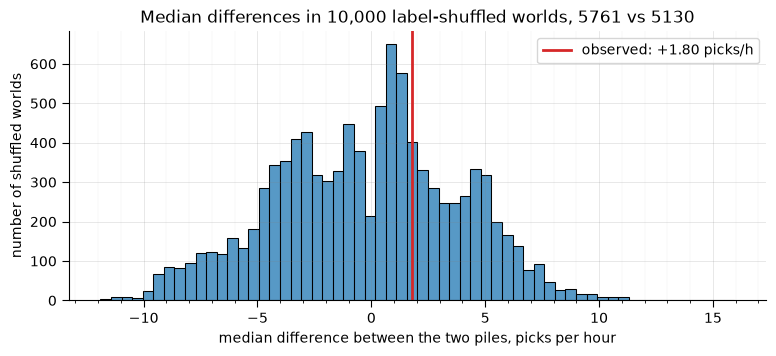

In [10]:
fig, ax = plt.subplots(figsize=(9, 3.5))

sns.histplot(luck_5761_vs_5130, bins=60, ax=ax)
ax.axvline(
    observed_difference,
    color="tab:red",
    lw=2,
    label=f"observed: {observed_difference:+.2f} picks/h",
)
ax.set_title("Median differences in 10,000 label-shuffled worlds, 5761 vs 5130")
ax.set_xlabel("median difference between the two piles, picks per hour")
ax.set_ylabel("number of shuffled worlds")
ax.legend()
make_ax_better(ax, minor="x")

plt.show()

Our red line sits in the fat middle of the hill. Coin-flip worlds produce a gap of a couple of picks per hour *routinely*. We have to count how routinely.

**The p-value, defined on this picture:** the share of luck-worlds whose difference is at least as big as ours. Two things happen in the one line that computes it:

- `.abs()` drops the signs on both sides, on a whole column as easily as on one number. That is us asking for a difference this big **in either direction**: the two-sided question, and the honest default unless you promised the direction in advance;
- what comes back is a mask, and its mean is the answer, the session-2 idiom, *the mean of a True/False column is a share*.

In [11]:
beats_us = luck_5761_vs_5130.abs() >= abs(observed_difference)
p_value = beats_us.mean()

print(
    f"luck-worlds at least as extreme as ours: {beats_us.sum():,} of "
    f"{len(luck_5761_vs_5130):,}\n"
    f"p-value = {p_value:.2f}"
)

luck-worlds at least as extreme as ours: 6,588 of 10,000
p-value = 0.66


✅ **What it means:** two thirds of pure-luck worlds beat our observation. Whatever we are looking at, luck reproduces it without breaking a sweat, so we have **no evidence** that these sectors differ in pace. In a report: *"no difference detected (permutation test, p = 0.66)"*.

⛔ **What it does NOT mean:** that the two sectors are equal. A big p-value is a failure to find a difference, not proof of sameness. With 304 and 621 tasks we could only ever have caught a *large* gap. "We found nothing" and "there is nothing" are different sentences, and mixing them up is how forecasts get promised to boards.

---

## 5. ❓ Same machine, the pair that looked most different

<details>
<summary>🔍 <b>What we'll do</b> — nothing new: the same function on another pair</summary>

Session 3's sector boxplot had two extremes: sector 5402 with the fastest median and 5400 with the slowest. Back then we refused to call one worse than the other, because their boxes overlapped heavily. Overlap is a warning, not a verdict. So let's finally run the test.
</details>

In [12]:
pace_5402 = tasks.loc[tasks["sector"] == 5402, "picks_per_hour"].dropna()
pace_5400 = tasks.loc[tasks["sector"] == 5400, "picks_per_hour"].dropna()

observed_difference_far = pace_5402.median() - pace_5400.median()
print(
    f"sector 5402: median {pace_5402.median():.1f} picks/h (n = {len(pace_5402)})\n"
    f"sector 5400: median {pace_5400.median():.1f} picks/h (n = {len(pace_5400)})\n"
    f"observed difference: {observed_difference_far:+.2f} picks/h"
)

sector 5402: median 149.9 picks/h (n = 423)
sector 5400: median 113.3 picks/h (n = 1015)
observed difference: +36.54 picks/h


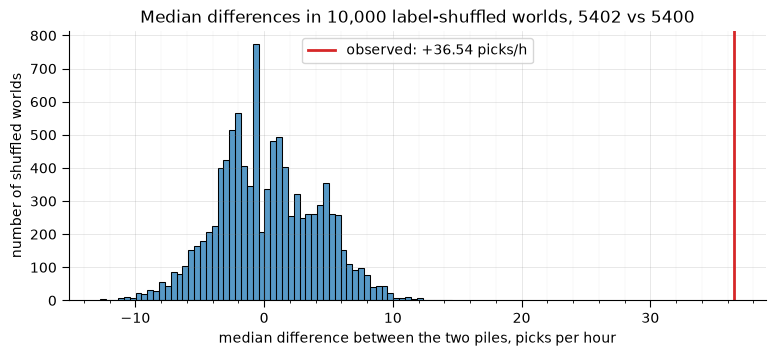

luck-worlds at least as extreme as ours: 0 of 10,000


In [13]:
luck_5402_vs_5400 = simulate_luck_differences(
    pace_5402.to_numpy(),
    pace_5400.to_numpy(),
)

fig, ax = plt.subplots(figsize=(9, 3.5))

sns.histplot(luck_5402_vs_5400, bins=60, ax=ax)
ax.axvline(
    observed_difference_far,
    color="tab:red",
    lw=2,
    label=f"observed: {observed_difference_far:+.2f} picks/h",
)
ax.set_title("Median differences in 10,000 label-shuffled worlds, 5402 vs 5400")
ax.set_xlabel("median difference between the two piles, picks per hour")
ax.set_ylabel("number of shuffled worlds")
ax.legend()
make_ax_better(ax, minor="x")

plt.show()

beats_us_far = luck_5402_vs_5400.abs() >= abs(observed_difference_far)
print(
    f"luck-worlds at least as extreme as ours: {beats_us_far.sum()} of "
    f"{len(luck_5402_vs_5400):,}"
)

✅ **What it means:** not one shuffle in ten thousand came close. We report **p < 0.0001**: luck essentially cannot manufacture a gap of thirty-six picks per hour between these two sectors, so the gap is real and worth a walk to the shelves. Same warehouse, same week, same code as five minutes ago: one comparison was noise, this one is iron-clad. Now we can *tell them apart*.

⛔ **What it does NOT mean:** p = 0. We ran ten thousand worlds, so the smallest number our machine can produce is "fewer than one in ten thousand", so write `p < 0.0001`, never `p = 0`. And it does not mean 5400's people are slower: a sector is a place, with its own layout, item mix and shift pattern. The test says *the difference is not luck*. It says nothing about *why*.

---

## 6. Naming what we built

- **Null hypothesis** — "the labels don't matter": the coin-flip world we simulated ten thousand times.
- **p-value** — the share of null worlds at least as extreme as reality.
- **Reject the null** — what we do when that share is tiny. The bar (0.05, 0.01) is a *convention agreed before looking*, priced by how much a false alarm costs you.

Textbook words, but you watched them happen first, and that is the only order that works.

And the named tests from statistics courses? **Pre-computed luck machines.** Mathematicians solved the shuffle analytically, for particular assumptions, so you get the p-value without the loop. Two of them cover almost everything you will do:

- **`stats.ttest_ind(group_a, group_b)`** — Student's t-test. It compares the two **means**, it is the answer every textbook gives, and it is **our default**.
- **`stats.mannwhitneyu(group_a, group_b)`** — the Mann-Whitney U test. It puts every value in order and compares the **ranks**, so no single huge value can pull it around. We reach for it as a **second opinion** when the mean stops describing the typical case, which happens after the break.

Both take the two groups and return a small result object; the field we want is `.pvalue`.

**One reading skill before the output.** Session 1 met `3.115430e+05`: the dot moves five places to the **right**, so 311,543. A **minus** in the exponent moves it the other way. `1.3e-22` is the dot moved twenty-two places to the **left**, a number with twenty-one zeros after the point. The rule is short and worth saying out loud: *the bigger the number after `e-`, the smaller the p-value.*

In [14]:
from scipy import stats

# equal_var=False is Welch's version. It costs nothing when the two groups have
# the same spread and saves you when they do not, so we always pass it
ttest_5761_vs_5130 = stats.ttest_ind(pace_5761, pace_5130, equal_var=False)
ttest_5402_vs_5400 = stats.ttest_ind(pace_5402, pace_5400, equal_var=False)
mannwhitney_5761_vs_5130 = stats.mannwhitneyu(pace_5761, pace_5130)
mannwhitney_5402_vs_5400 = stats.mannwhitneyu(pace_5402, pace_5400)

print(
    f"5761 vs 5130:  t-test p = {ttest_5761_vs_5130.pvalue:.2f}"
    f"   Mann-Whitney p = {mannwhitney_5761_vs_5130.pvalue:.2f}\n"
    f"5402 vs 5400:  t-test p = {ttest_5402_vs_5400.pvalue:.1e}"
    f"   Mann-Whitney p = {mannwhitney_5402_vs_5400.pvalue:.1e}"
)

5761 vs 5130:  t-test p = 0.38   Mann-Whitney p = 0.48
5402 vs 5400:  t-test p = 1.3e-22   Mann-Whitney p = 2.8e-26


✅ **What it means:** three machines, the same two verdicts. Nothing on the first pair, a certainty on the second. The decimals differ — 0.38 from the t-test, 0.48 from the ranks, 0.66 from our ten thousand shuffles — because they are genuinely different machines, working on means, on ranks and on medians. **Verdicts agree; decimals need not.** From now on we mostly type a one-liner, but you know what is inside it.

⛔ **What it does NOT mean:** that `1e-22` is "more significant" than `p < 0.0001`. Both say *luck is not the explanation*, and neither says the effect is big. Size is a separate question, and it gets its own trap after the break.

---

## Try it yourself

1. Pick two **other** sectors, run the machine, report your p-value and your verdict in one sentence.
2. Change `simulate_luck_differences` to compare **means** instead of medians. Does the 5761 vs 5130 verdict change? Why might it?
3. Session 3 left ALPHA against BRAVO hanging: "whether that gap is bigger than luck is next week's lecture". Both sites sit next to each other: `../../data/alpha` and `../../data/bravo`. Build the task table for each and settle it.
4. Which pair of sectors would the *manager* care about most? Test that one.

In [15]:
# your turn

## Recap

- Luck impersonates signal, so always ask "what would pure chance produce here?"
- **The question a p-value answers: if the two groups really were one and the same, how often would chance alone hand me a gap this big?**
- The permutation test answers it by simulation: **p = the share of label-shuffled worlds at least as extreme as yours**.
- p = 0.66 → nothing found (which is *not* "nothing is there"); p < 0.0001 → real (report `<`, never "= 0").
- Named tests are pre-solved shuffles: one line of scipy, `.pvalue` inside. **`ttest_ind(a, b, equal_var=False)` is our default** (it compares means; Welch's version costs nothing and protects you when the spreads differ); `mannwhitneyu` is the second opinion (it compares ranks).
- The bar (0.05, 0.01) is a convention agreed *before looking*, not physics.
- New tools: `numpy` arrays (`np.array`, `np.median`, `np.concatenate`, `default_rng`, `permutation`), `stats.ttest_ind` and `stats.mannwhitneyu`.